C:\Users\tesse\AppData\Local\Temp\ipykernel_27800\2185053827.py:31: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  T_root = fsolve(equation, guess, args=(x, beta))


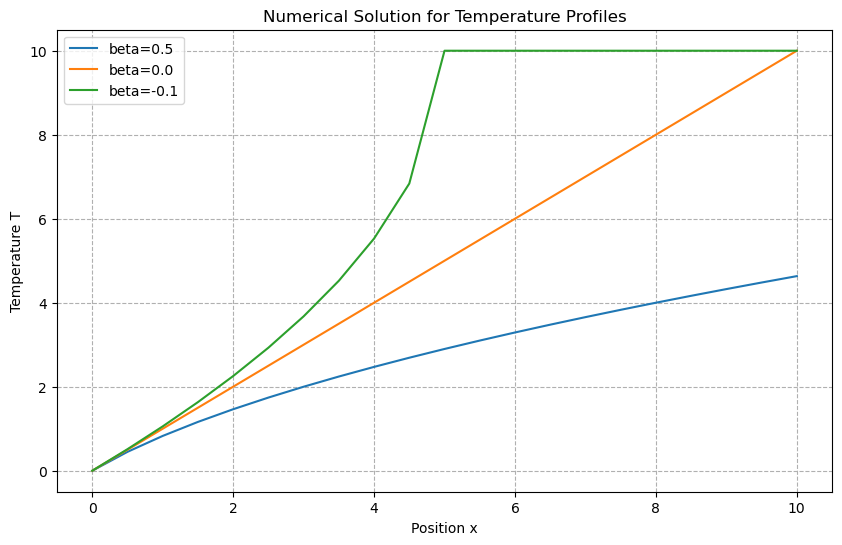

     x  T(beta=0.5)  T(beta=0.0)  T(beta=-0.1)
0  0.0     0.000000          0.0      0.000000
1  0.5     0.449490          0.5      0.513167
2  1.0     0.828427          1.0      1.055728
3  1.5     1.162278          1.5      1.633400
4  2.0     1.464102          2.0      2.254033


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import fsolve

# 1. Define Constants
k0, C0, C1 = 1.0, 1.0, 0.0
betas = [0.5, 0.0, -0.1]

# 2. Define the implicit equation to solve: f(T) = 0
def equation(T, x, beta):
    lhs = k0 * (T + beta * T**2 / 2)
    rhs = C0 * x + C1
    return lhs - rhs

# 3. Define our X domain (The Independent Variable)
x_values = np.linspace(0, 10, 21) # 21 points for a clean table

# Store results to display later
results = {'x': x_values}

plt.figure(figsize=(10, 6))

for beta in betas:
    T_solution = []
    guess = 0.0 # Initial guess for the solver
    
    for x in x_values:
        # fsolve finds the root of 'equation' starting from 'guess'
        # args passes the fixed parameters (x, beta) to the function
        T_root = fsolve(equation, guess, args=(x, beta))
        
        T_val = T_root[0]
        T_solution.append(T_val)
        guess = T_val # Update guess to current T for speed
        
    # Save to our results dictionary
    results[f'T(beta={beta})'] = T_solution
    
    # Plot
    plt.plot(x_values, T_solution, label=f'beta={beta}')

# Formatting plot
plt.title('Numerical Solution for Temperature Profiles')
plt.xlabel('Position x')
plt.ylabel('Temperature T')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

# 4. Show the Numerical Data (The Table)
df = pd.DataFrame(results)
print(df.head()) # Shows the first 5 rows